In [25]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from PyLTSpice import RawRead
import matplotlib.pyplot as plt
import random

In [26]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(33882356)

In [27]:
class RCDataset(Dataset):
    def __init__(self,data_file):
        data = np.load(data_file) # load numpy file

        # store mag phase and RC data to separate variables
        mag = data[:,0,1:]
        phase = data[:,1,1:]
        y = np.log10(data[:,1,0]).reshape(-1,1)
        
        # convert to dB
        mag = 20*np.log10(mag)

        self.mag_scaler = StandardScaler().fit(mag)
        self.phase_scaler = StandardScaler().fit(phase)
        self.y_scaler = StandardScaler().fit(y)

        mag = self.mag_scaler.transform(mag)
        phase = self.phase_scaler.transform(phase)
        y = self.y_scaler.transform(y)

        X = np.stack([mag, phase], axis=1)
        #X = mag[:, np.newaxis, :]

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [28]:
class RCNet(nn.Module):
    def __init__(self, input_dim=2, output_dim=1):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(32),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [29]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=100, patience=10, plot=True):
    best_val_loss = float("inf")
    patience_counter = 0
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.7, patience=5)

    # History for plotting
    history = {"train_loss": [], "val_loss": [], "lr": []}

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # --- Validation ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)

                '''
                base_loss = criterion(y_pred, y_batch)
                phys = physics_loss(y_pred, y_batch)
                val_loss += (base_loss + lambda_phys*phys).item()
                '''

                val_loss += criterion(y_pred, y_batch).item()

        val_loss /= len(val_loader)

        # Step LR scheduler
        scheduler.step(val_loss)

        # Record history
        current_lr = optimizer.param_groups[0]['lr']
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        # --- Print progress ---
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"LR: {current_lr:.2e}"
        )

        # --- Early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # --- Plot learning curves ---
    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(history["train_loss"], label="Train Loss")
        plt.plot(history["val_loss"], label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training & Validation Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(8, 3))
        plt.plot(history["lr"])
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("LR Schedule")
        plt.grid(True)
        plt.show()

    return history

Using device: cuda
Epoch 1/300 | Train Loss: 0.0166 | Val Loss: 0.0001 | LR: 1.00e-03
Epoch 2/300 | Train Loss: 0.0007 | Val Loss: 0.0000 | LR: 1.00e-03
Epoch 3/300 | Train Loss: 0.0006 | Val Loss: 0.0000 | LR: 1.00e-03
Epoch 4/300 | Train Loss: 0.0005 | Val Loss: 0.0001 | LR: 1.00e-03
Epoch 5/300 | Train Loss: 0.0005 | Val Loss: 0.0001 | LR: 1.00e-03
Epoch 6/300 | Train Loss: 0.0005 | Val Loss: 0.0001 | LR: 1.00e-03
Epoch 7/300 | Train Loss: 0.0005 | Val Loss: 0.0003 | LR: 1.00e-03
Epoch 8/300 | Train Loss: 0.0005 | Val Loss: 0.0001 | LR: 1.00e-03
Epoch 9/300 | Train Loss: 0.0005 | Val Loss: 0.0001 | LR: 7.00e-04
Epoch 10/300 | Train Loss: 0.0005 | Val Loss: 0.0001 | LR: 7.00e-04
Epoch 11/300 | Train Loss: 0.0004 | Val Loss: 0.0005 | LR: 7.00e-04
Epoch 12/300 | Train Loss: 0.0005 | Val Loss: 0.0000 | LR: 7.00e-04
Epoch 13/300 | Train Loss: 0.0005 | Val Loss: 0.0000 | LR: 7.00e-04
Epoch 14/300 | Train Loss: 0.0005 | Val Loss: 0.0001 | LR: 7.00e-04
Epoch 15/300 | Train Loss: 0.0005 | Va

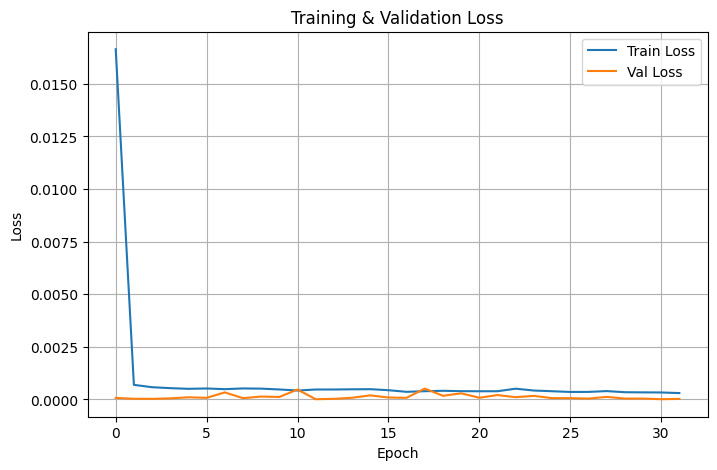

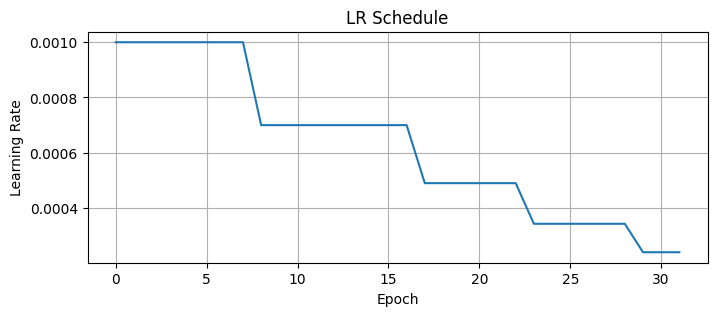

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#'''
# --- Dataset & DataLoaders ---
full_dataset = RCDataset("data.npy")
mag_scaler, phase_scaler, y_scaler = full_dataset.mag_scaler, full_dataset.phase_scaler, full_dataset.y_scaler

# Train / val / test split
total_len = len(full_dataset)
train_len = int(0.7 * total_len)
val_len = int(0.3 * total_len)

train_dataset, val_dataset = random_split(full_dataset, [train_len, val_len])
#'''

# batch size
bs = 32

train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

# --- Model, criterion, optimizer ---
model = RCNet().to(device)
criterion = nn.SmoothL1Loss(beta=2.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

# --- Train the model ---
history = train_model(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=300, patience=20, plot=True
)

In [31]:
#torch.save(model.state_dict(), "RC_model_phase.pth")

In [32]:
#model.load_state_dict(torch.load("RC_model_phase.pth", weights_only=True))

5000000000.0


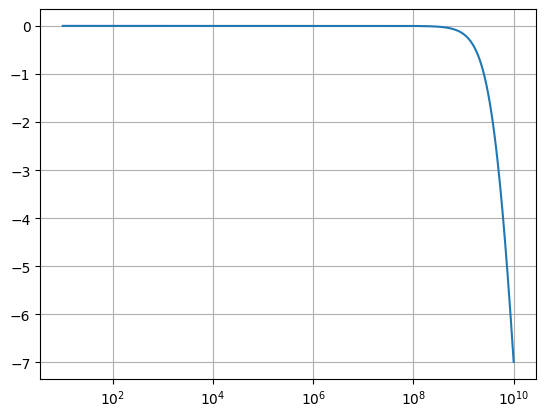

R = 6068 | C = 5.802e-15


In [61]:
f = np.logspace(np.log10(10), np.log10(10E9), 9*200)

fc = 5E9
print(fc)
hf = 1 / (1 + 1j*f/fc)

plt.semilogx(f, 20*np.log10(np.abs(hf)))
plt.grid()
plt.show()

mag = mag_scaler.transform([20*np.log10(np.abs(hf))])
phase = phase_scaler.transform([np.angle(hf)])

#test_X = mag[:, np.newaxis, :]
test_X = np.stack((mag,phase), axis=1)
test_X = torch.tensor(test_X, dtype=torch.float32).to(device)

model.eval()
predict = model(test_X)
predict = predict.detach().cpu().numpy()
predict = y_scaler.inverse_transform(predict)

predict = 10**predict
R = np.random.randint(1000, 50000)
C = predict/R
print(f"R = {round(R)} | C = {C[0][0]:.4g}")

Move onto bandpass
Get model working w/o phase

In [62]:
sim_fc = 4521973031.27

error = abs(fc - sim_fc)/fc*100
print(error)

9.56053937459999


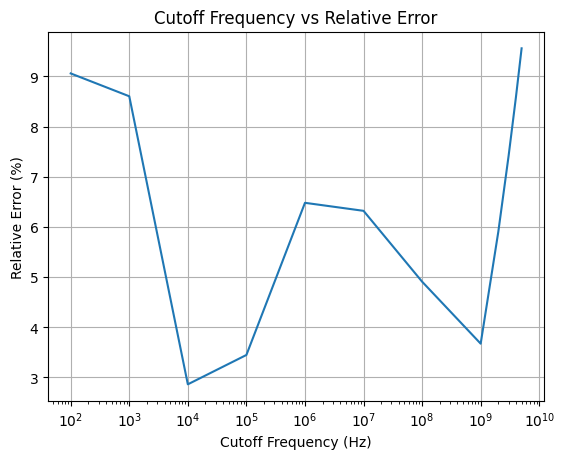

6.4025061875902765


In [64]:
f_test = [100, 1E3, 10E3, 100E3, 1E6, 10E6, 100E6, 1E9, 2E9, 3E9, 4E9, 5E9]
errors = [9.060168845999996, 8.604821149000008, 2.8631322519999958, 3.4481197620000024, 6.48099699899999, 6.321309762999992, 4.909521760000005, 3.673474815900004, 5.902762320000004, 7.418408458333333, 8.586818751250004, 9.56053937459999]

plt.semilogx(f_test, errors)
plt.title("Cutoff Frequency vs Relative Error")
plt.xlabel("Cutoff Frequency (Hz)")
plt.ylabel("Relative Error (%)")
plt.grid()
plt.show()

print(np.average(errors))